<a href="https://colab.research.google.com/github/Wambo44-master/Ngao-Labs-Capstone-Project/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
data = pd.read_excel('/content/knbs002-road-accident-casualties-qoabis.xlsx')
data.head()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   TIME_PERIOD   72 non-null     int64 
 1   GEO           72 non-null     object
 2   UNIT_MEASURE  72 non-null     object
 3   ROAD_USER     72 non-null     object
 4   INJURY_TYPE   72 non-null     object
 5   OBS_VALUE     72 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 3.5+ KB


,0
TIME_PERIOD,0
GEO,0
UNIT_MEASURE,0
ROAD_USER,0
INJURY_TYPE,0
OBS_VALUE,0


In [2]:
meta = pd.read_excel('/content/metadata-knbs002-f2vtlp.xlsx')
meta.head()
meta2 = pd.read_excel('/content/metadata-knbs003-j0fprx.xlsx')
meta2.head()

,Attribute name,Value
0,Data flow ID,KNBS003
1,Data provider,Ministry of Transport
2,URL or web address,https://www.transport.go.ke/
3,Measure (‘indicator’),Total number of road accidents
4,Unit of measure,number of accidents


In [3]:
data['TIME_PERIOD']

,TIME_PERIOD
0,2018
1,2018
2,2018
3,2018
4,2018
...,...
67,2021
68,2021
69,2021
70,2021


In [4]:
data['OBS_VALUE']

,OBS_VALUE
0,1205
1,851
2,256
3,306
4,496
...,...
67,110
68,19
69,1270
70,2501


In [5]:
data['INJURY_TYPE']

,INJURY_TYPE
0,Killed
1,Seriously Injured
2,Slightly Injured
3,Killed
4,Seriously Injured
...,...
67,Seriously Injured
68,Slightly Injured
69,Killed
70,Seriously Injured


In [6]:
data['ROAD_USER']

,ROAD_USER
0,Pedestrians
1,Pedestrians
2,Pedestrians
3,Drivers
4,Drivers
...,...
67,Pedal Cyclist
68,Pedal Cyclist
69,Motor Cyclist
70,Motor Cyclist


In [7]:
data['UNIT_MEASURE']

,UNIT_MEASURE
0,number of people
1,number of people
2,number of people
3,number of people
4,number of people
...,...
67,number of people
68,number of people
69,number of people
70,number of people


In [8]:
data.head()

,TIME_PERIOD,GEO,UNIT_MEASURE,ROAD_USER,INJURY_TYPE,OBS_VALUE
0,2018,KE,number of people,Pedestrians,Killed,1205
1,2018,KE,number of people,Pedestrians,Seriously Injured,851
2,2018,KE,number of people,Pedestrians,Slightly Injured,256
3,2018,KE,number of people,Drivers,Killed,306
4,2018,KE,number of people,Drivers,Seriously Injured,496


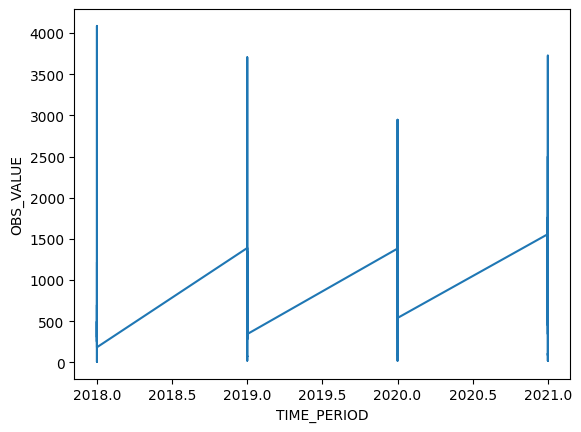

In [9]:
#Visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
plt.plot(data['TIME_PERIOD'],data['OBS_VALUE'])
plt.xlabel('TIME_PERIOD')
plt.ylabel('OBS_VALUE')
plt.show()

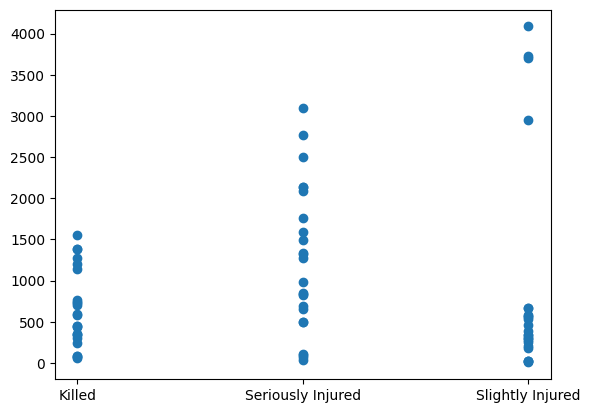

In [10]:
plt.scatter(data['INJURY_TYPE'],data['OBS_VALUE'])
plt.show()

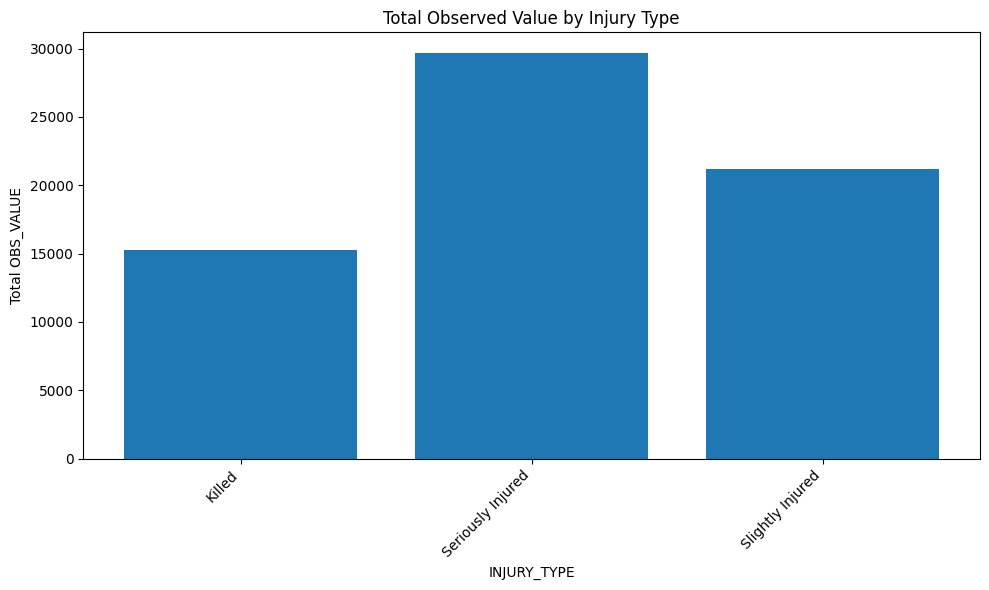

In [11]:

#Plot a bar plot to show agg.  numerical values for the categorical col Injury type and reset index
injury_type_summary = data.groupby('INJURY_TYPE')['OBS_VALUE'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(injury_type_summary['INJURY_TYPE'], injury_type_summary['OBS_VALUE'])
plt.xlabel('INJURY_TYPE')
plt.ylabel('Total OBS_VALUE')
plt.title('Total Observed Value by Injury Type')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [12]:
data.dtypes=='object'

,0
TIME_PERIOD,False
GEO,True
UNIT_MEASURE,True
ROAD_USER,True
INJURY_TYPE,True
OBS_VALUE,False


In [13]:
data.TIME_PERIOD.value_counts()

,count
TIME_PERIOD,
2018,18
2019,18
2020,18
2021,18


FEATURE ENGINEERING


In [14]:
# 1. Pivot Table
data_pivot = data.pivot_table(
    index=['TIME_PERIOD', 'ROAD_USER'],
    columns='INJURY_TYPE',
    values='OBS_VALUE',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 2. Feature Engineering
# Create a Total column
data_pivot['Total_Casualties'] = data_pivot[['Killed', 'Seriously Injured', 'Slightly Injured']].sum(axis=1)

# Calculate Fatality Rate
data_pivot['Fatality_Rate'] = (data_pivot['Killed'] / data_pivot['Total_Casualties']) * 100

# Calculate Serious Injury Rate
data_pivot['Serious_Injury_Rate'] = (data_pivot['Seriously Injured'] / data_pivot['Total_Casualties']) * 100

print(data_pivot.head())


INJURY_TYPE  TIME_PERIOD      ROAD_USER  Killed  Seriously Injured  \
0                   2018        Drivers     306                496   
1                   2018  Motor Cyclist     591                698   
2                   2018     Passengers     746               2093   
3                   2018  Pedal Cyclist      63                 36   
4                   2018    Pedestrians    1205                851   

INJURY_TYPE  Slightly Injured  Total_Casualties  Fatality_Rate  \
0                         307              1109      27.592426   
1                         184              1473      40.122200   
2                        4087              6926      10.771008   
3                           6               105      60.000000   
4                         256              2312      52.119377   

INJURY_TYPE  Serious_Injury_Rate  
0                      44.724977  
1                      47.386286  
2                      30.219463  
3                      34.285714  
4      

In [15]:
data_pivot.head()

INJURY_TYPE,TIME_PERIOD,ROAD_USER,Killed,Seriously Injured,Slightly Injured,Total_Casualties,Fatality_Rate,Serious_Injury_Rate
0,2018,Drivers,306,496,307,1109,27.592426,44.724977
1,2018,Motor Cyclist,591,698,184,1473,40.122200,47.386286
2,2018,Passengers,746,2093,4087,6926,10.771008,30.219463
3,2018,Pedal Cyclist,63,36,6,105,60.000000,34.285714
4,2018,Pedestrians,1205,851,256,2312,52.119377,36.807958


In [21]:
# 1. Map the data to include Vulnerable and Protected group for a new col called User Group
vulnerability = {
    'Pedestrians': 'Vulnerable',
    'Pedal Cyclist': 'Vulnerable',
    'Motor Cyclist': 'Vulnerable',
    'Drivers': 'Protected',
    'Passengers': 'Protected',
    'Pillion Passengers':'Vulnerable'
}

data_pivot['User_Group'] = data_pivot['ROAD_USER'].map(vulnerability)

# 2. Calculate Yearly Trend of accidents
# This lets you see progress for EACH specific type
data_pivot = data_pivot.sort_values(['ROAD_USER', 'TIME_PERIOD'])
data_pivot['Yearly_Trend'] = data_pivot.groupby('ROAD_USER')['Total_Casualties'].pct_change() * 100

print(data_pivot[['TIME_PERIOD', 'ROAD_USER', 'User_Group', 'Total_Casualties', 'Yearly_Trend']].head(10))


INJURY_TYPE  TIME_PERIOD      ROAD_USER  User_Group  Total_Casualties  \
0                   2018        Drivers   Protected              1109   
6                   2019        Drivers   Protected              1461   
12                  2020        Drivers   Protected              1753   
18                  2021        Drivers   Protected              2105   
1                   2018  Motor Cyclist  Vulnerable              1473   
7                   2019  Motor Cyclist  Vulnerable              2410   
13                  2020  Motor Cyclist  Vulnerable              3818   
19                  2021  Motor Cyclist  Vulnerable              4335   
2                   2018     Passengers   Protected              6926   
8                   2019     Passengers   Protected              7180   

INJURY_TYPE  Yearly_Trend  
0                     NaN  
6               31.740307  
12              19.986311  
18              20.079863  
1                     NaN  
7               63.611677  


In [22]:
data_pivot.head()
data_pivot.drop_duplicates()
data_pivot.head()
data_pivot.columns.to_list()
#Check for missing values in your data
#fill missing values
data_pivot['Yearly_Trend'] = data_pivot['Yearly_Trend'].fillna(0)
data_pivot.isnull().sum()

,0
INJURY_TYPE,
TIME_PERIOD,0
ROAD_USER,0
Killed,0
Seriously Injured,0
Slightly Injured,0
Total_Casualties,0
Fatality_Rate,0
Serious_Injury_Rate,0
User_Group,0


In [23]:
data_pivot['User_Group']

,User_Group
0,Protected
6,Protected
12,Protected
18,Protected
1,Vulnerable
7,Vulnerable
13,Vulnerable
19,Vulnerable
2,Protected
8,Protected
